<a href="https://colab.research.google.com/github/nhbintifr/ReplikasiJurnal_datascience/blob/main/%5Bdatascience%5D_Tugas_Replikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install library tambahan yang belum ada di Colab
!pip install imbalanced-learn -q

In [ ]:
#data manipulation
import pandas as pd
import numpy as np

#data visualisasi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

#model ML
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split, GridSearchCV

#evaluasi
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [ ]:
#load dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

df = pd.read_csv(url, header=None, names=columns)

print(f"✅ Dataset dimuat: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"\nDistribusi kelas:")
print(f"  Tidak Diabetes (0): {(df['Outcome']==0).sum()}")
print(f"  Diabetes       (1): {(df['Outcome']==1).sum()}")
df.head()

✅ Dataset dimuat: 768 baris × 9 kolom

Distribusi kelas:
  Tidak Diabetes (0): 500
  Diabetes       (1): 268


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1mmMFHmJ4fIRax7DEgQOpPaQGOjfk-DGnj9OSdEWrnPI/edit#gid=0


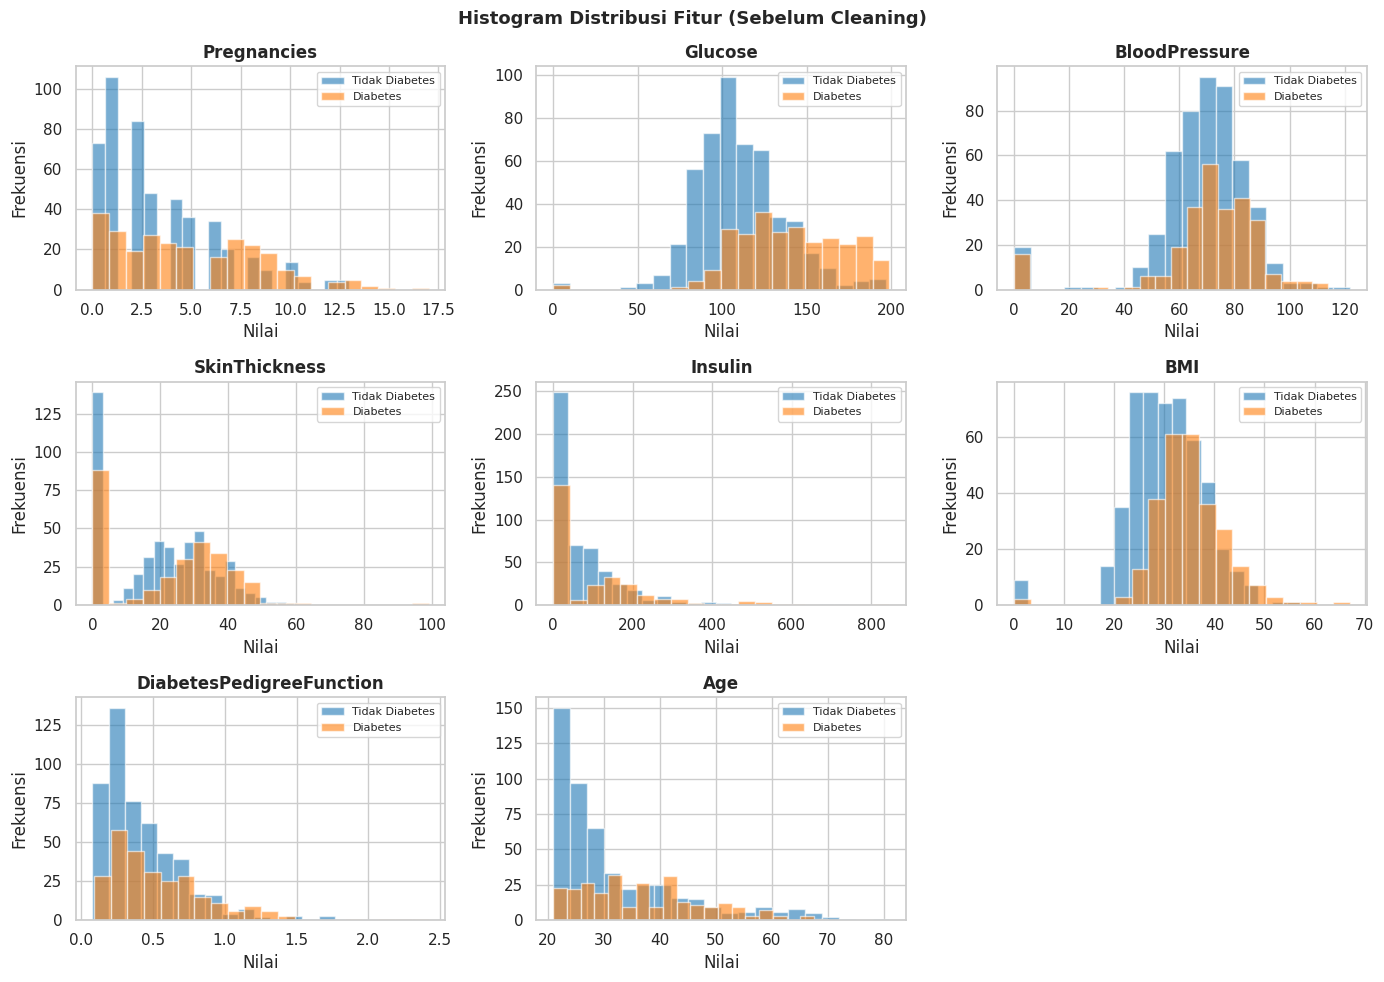

In [ ]:
# EDA
# Histogram semua fitur (sebelum cleaning)
# "df.drop" di sini = drop kolom Outcome untuk lihat distribusi fitur saja
features_only = df.drop(columns=['Outcome'])

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_only.columns):
    axes[i].hist(df[df['Outcome']==0][col], bins=20, alpha=0.6,
                 color='#1f77b4', label='Tidak Diabetes', edgecolor='white')
    axes[i].hist(df[df['Outcome']==1][col], bins=20, alpha=0.6,
                 color='#ff7f0e', label='Diabetes', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

# Sembunyikan panel kosong
axes[-1].set_visible(False)

fig.suptitle('Histogram Distribusi Fitur (Sebelum Cleaning)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# EDA
# Kolom yang ga mungkin bernilai 0 secara medis
zero_not_valid = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

print("Jumlah nilai 0 yang tidak valid per kolom:")
for col in zero_not_valid:
    n = (df[col] == 0).sum()
    print(f"  {col:<25}: {n} nilai nol")

# Replace 0 → NaN
# df tetap 768 baris — tidak ada yang di-drop. Ditandain sebagai missing, nanti akan diisi dengan SimpleImputer setelah split
df[zero_not_valid] = df[zero_not_valid].replace(0, np.nan)

print(f"\nTotal baris setelah replace: {df.shape[0]} (tetap 768 ✅)")
print(f"\nJumlah NaN per kolom:")
print(df.isnull().sum().to_string())

Jumlah nilai 0 yang tidak valid per kolom:
  Glucose                  : 5 nilai nol
  BloodPressure            : 35 nilai nol
  SkinThickness            : 227 nilai nol
  Insulin                  : 374 nilai nol
  BMI                      : 11 nilai nol

Total baris setelah replace: 768 (tetap 768 ✅)

Jumlah NaN per kolom:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0


In [ ]:
# EDA : Cek nilai statistik dataset
print("="*85)
print("TABLE 2 JURNAL — Statistical Values")
print("="*85)
stats = df.describe().round(2)
print(stats.to_string())
print()
print("Penjelasan count yang berbeda:")
print("  Count ≠ 768 karena pandas describe() hanya hitung non-null values")
print("  → ini BUKAN karena baris di-drop, tapi karena 0 sudah jadi NaN")
print()

# Verifikasi vs Table 2 jurnal
target_counts = {
    'Pregnancies': 768, 'Glucose': 763, 'BloodPressure': 733,
    'SkinThickness': 541, 'Insulin': 394, 'BMI': 757,
    'DiabetesPedigreeFunction': 768, 'Age': 768, 'Outcome': 768
}
print("Perbandingan count vs Table 2 di jurnal:")
for col, target in target_counts.items():
    actual = int(stats.loc['count', col])
    status = '✅' if actual == target else '❌'
    print(f"  {col:<25}: hasil={actual}, target={target} {status}")

TABLE 2 JURNAL — Statistical Values
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  DiabetesPedigreeFunction     Age  Outcome
count       768.00   763.00         733.00         541.00   394.00  757.00                    768.00  768.00   768.00
mean          3.85   121.69          72.41          29.15   155.55   32.46                      0.47   33.24     0.35
std           3.37    30.54          12.38          10.48   118.78    6.92                      0.33   11.76     0.48
min           0.00    44.00          24.00           7.00    14.00   18.20                      0.08   21.00     0.00
25%           1.00    99.00          64.00          22.00    76.25   27.50                      0.24   24.00     0.00
50%           3.00   117.00          72.00          29.00   125.00   32.30                      0.37   29.00     0.00
75%           6.00   141.00          80.00          36.00   190.00   36.60                      0.63   41.00     1.00
max          17.00  

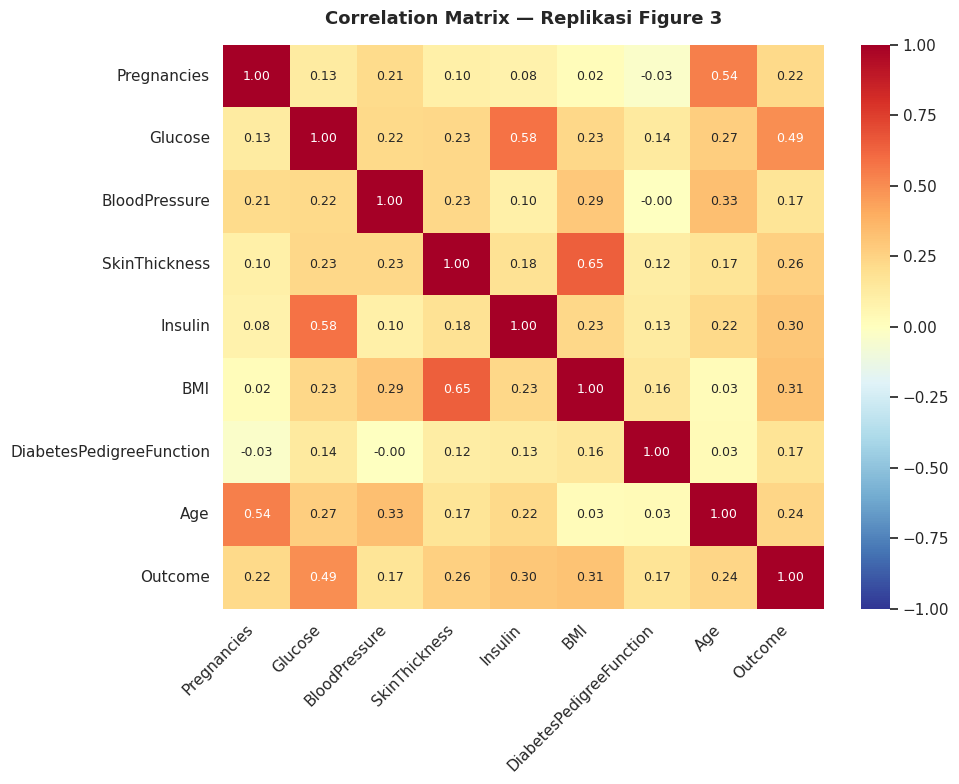


Korelasi tertinggi terhadap Outcome:
Glucose                     0.495
BMI                         0.314
Insulin                     0.303
SkinThickness               0.259
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
BloodPressure               0.171


In [ ]:
# EDA: Correlation Matrix (Versi Bersih & Profesional)
plt.figure(figsize=(10, 8))
corr = df.corr()

# Menggunakan Seaborn heatmap agar angka presisi di tengah dan tanpa garis potong
sns.heatmap(
    corr,
    annot=True,          # Menampilkan angka korelasi
    fmt=".2f",           # Format 2 angka di belakang koma
    cmap='RdYlBu_r',     # Palette warna sesuai jurnal
    vmin=-1, vmax=1,     # Rentang skala korelasi
    center=0,            # Titik tengah warna pada angka 0
    linewidths=0,        # MENGHILANGKAN garis antar kotak
    linecolor='none',    # Memastikan tidak ada sisa garis
    annot_kws={"size": 9} # Ukuran font angka di dalam kotak
)

plt.title('Correlation Matrix — Replikasi Figure 3',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nKorelasi tertinggi terhadap Outcome:")
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3).to_string())

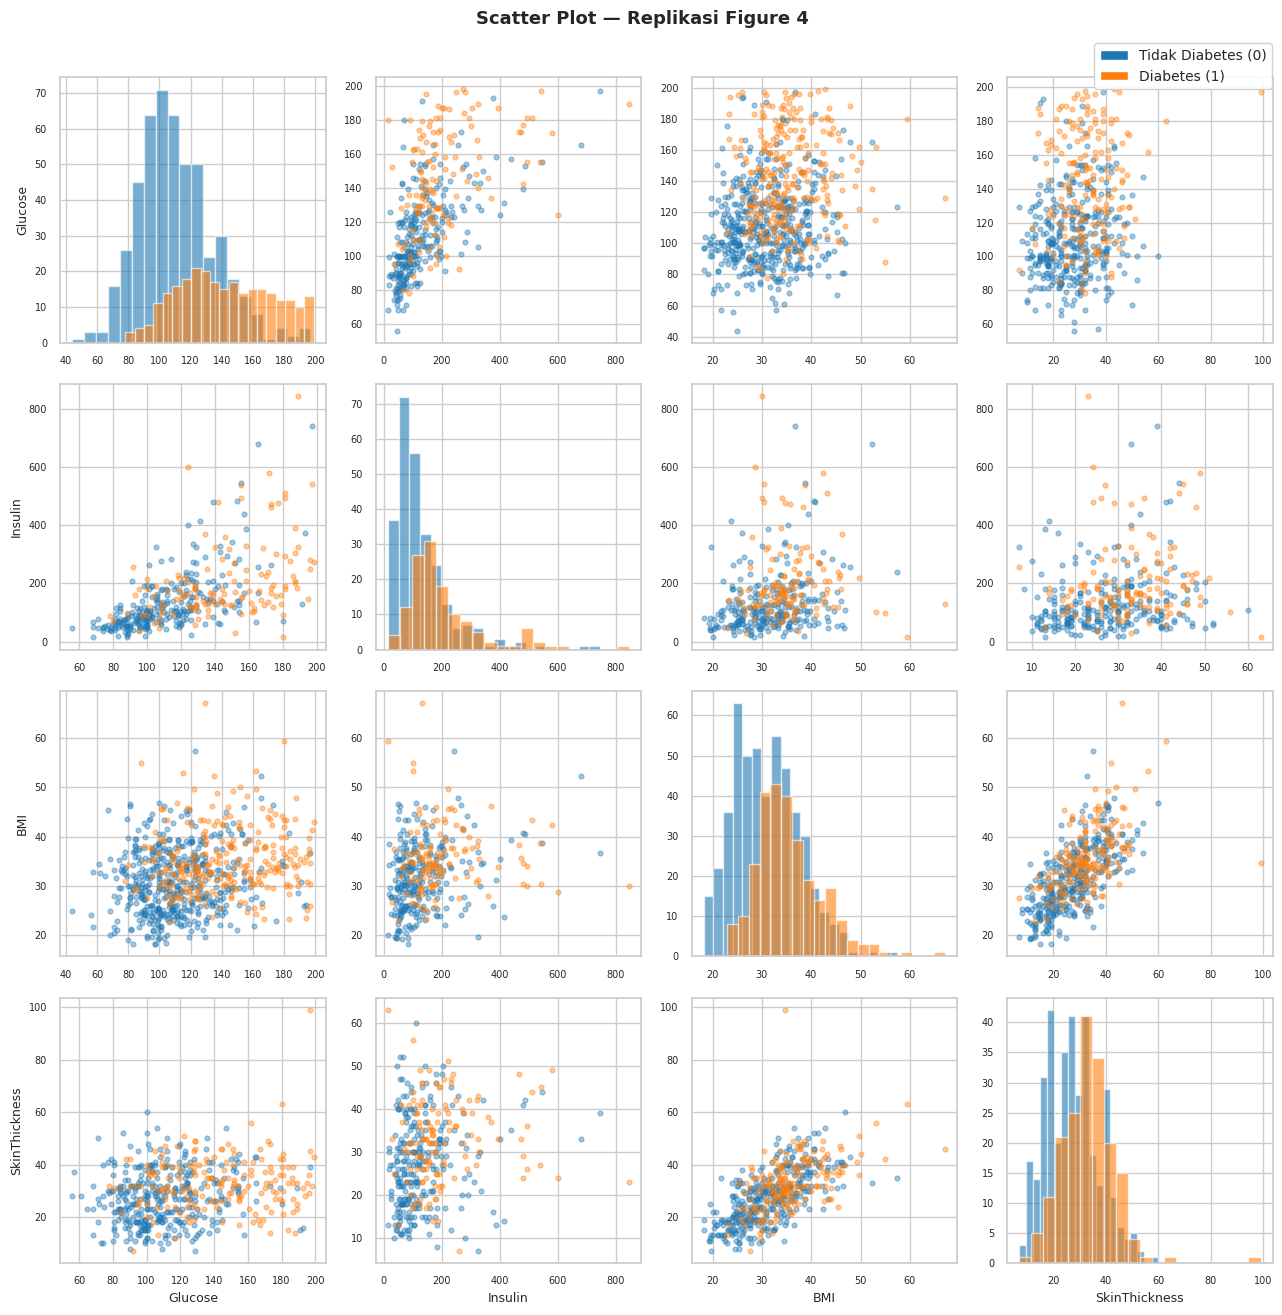

In [ ]:
# EDA
# Scatter plot dengan 4 variabel aja yang tertinggi korelasi dari Corr Matrix
scatter_vars = ['Glucose', 'Insulin', 'BMI', 'SkinThickness']
colors = {0: '#1f77b4', 1: '#ff7f0e'}
labels = {0: 'Tidak Diabetes', 1: 'Diabetes'}

fig, axes = plt.subplots(4, 4, figsize=(13, 13))

for row in range(4):
    for col in range(4):
        ax = axes[row][col]

        if row == col:
            # Diagonal: histogram per kelas
            for outcome in [0, 1]:
                mask = df['Outcome'] == outcome
                data = df[mask][scatter_vars[row]].dropna()
                ax.hist(data, bins=20, alpha=0.6,
                       color=colors[outcome], edgecolor='white')
        else:
            # Off-diagonal: scatter plot
            # NaN otomatis di-skip oleh matplotlib
            for outcome in [0, 1]:
                mask = df['Outcome'] == outcome
                ax.scatter(
                    df[mask][scatter_vars[col]],
                    df[mask][scatter_vars[row]],
                    c=colors[outcome], alpha=0.4, s=12,
                    label=labels[outcome]
                )

        # Label sumbu hanya di tepi
        if row == 3:
            ax.set_xlabel(scatter_vars[col], fontsize=9)
        else:
            ax.set_xlabel('')
        if col == 0:
            ax.set_ylabel(scatter_vars[row], fontsize=9)
        else:
            ax.set_ylabel('')

        ax.tick_params(labelsize=7)

# Legend di luar
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Tidak Diabetes (0)'),
                   Patch(facecolor='#ff7f0e', label='Diabetes (1)')]
fig.legend(handles=legend_elements, loc='upper right',
           bbox_to_anchor=(0.99, 0.99), fontsize=10, framealpha=0.9)

fig.suptitle('Scatter Plot — Replikasi Figure 4',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# BENTUK NORMAL & BENAR (MENCEGAH DATA LEAKAGE)
# =========================================================

# 1. SPLIT DATA (80/20) DENGAN STRATIFY
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Membagi data DULU sebelum diapa-apakan
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Split Data Selesai!")
print(f"Train set : {X_train.shape[0]} baris")
print(f"Test set  : {X_test.shape[0]} baris")

# 2. IMPUTASI (Isi nilai NaN)
# Aturan Emas: Fit HANYA pada X_train, Transform pada X_train & X_test
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# 3. NORMALISASI / STANDARISASI
# Aturan Emas: Fit HANYA pada X_train, Transform pada X_train & X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Simpan untuk dataset varian Original
X_train_orig = X_train_scaled
y_train_orig = y_train.values

# 4. SMOTE (HANYA PADA X_TRAIN)
# Kita seimbangkan kelas hanya untuk data belajar (train), data ujian (test) biarkan natural
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"\n✅ SMOTE Selesai (Hanya pada Data Train)!")
print(f"Distribusi SEBELUM SMOTE : {dict(y_train.value_counts())}")
print(f"Distribusi SETELAH SMOTE : {dict(pd.Series(y_train_sm).value_counts())}")

# 5. PCA (REDUKSI DIMENSI)
# Aturan Emas: Fit HANYA pada X_train, Transform pada X_train & X_test
# Kita gunakan 5 komponen (atau sesuai kebutuhan Anda) agar tidak sama dengan jumlah fitur asli
pca_model = PCA(n_components=2)
X_train_pca = pca_model.fit_transform(X_train_scaled)
X_test_pca  = pca_model.transform(X_test_scaled)
y_train_pca = y_train.values

print(f"\n✅ PCA Selesai (menggunakan {pca_model.n_components_} komponen)!")
print(f"Total variance explained: {pca_model.explained_variance_ratio_.sum()*100:.2f}%")

# 6. SETUP DATASET VARIANTS UNTUK DI-LOOPING DI MODEL ML
# Perhatikan bahwa semua varian menggunakan X_test_scaled atau X_test_pca yang asli (tidak di-SMOTE)
dataset_variants = {
    'Original': (X_train_orig, y_train_orig, X_test_scaled, 'accuracy'),
    'SMOTE':    (X_train_sm,   y_train_sm,   X_test_scaled, 'accuracy'),
    'PCA':      (X_train_pca,  y_train_pca,  X_test_pca,    'accuracy'),
}

✅ Split Data Selesai!
Train set : 614 baris
Test set  : 154 baris

✅ SMOTE Selesai (Hanya pada Data Train)!
Distribusi SEBELUM SMOTE : {0: np.int64(400), 1: np.int64(214)}
Distribusi SETELAH SMOTE : {0: np.int64(400), 1: np.int64(400)}

✅ PCA Selesai (menggunakan 2 komponen)!
Total variance explained: 48.20%


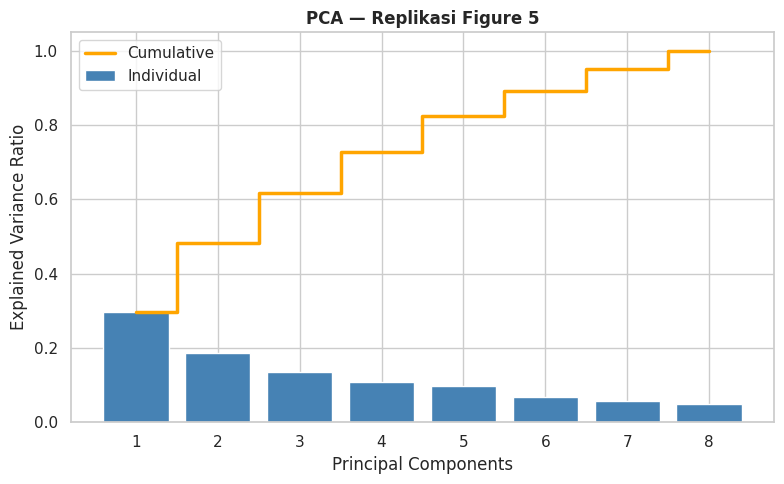

Explained variance ratio per komponen:
  PC1: 0.297 (29.7% kumulatif)
  PC2: 0.186 (48.2% kumulatif)
  PC3: 0.137 (61.9% kumulatif)
  PC4: 0.109 (72.8% kumulatif)
  PC5: 0.097 (82.5% kumulatif)
  PC6: 0.068 (89.3% kumulatif)
  PC7: 0.058 (95.1% kumulatif)
  PC8: 0.049 (100.0% kumulatif)


In [ ]:
# Visualisasi PCA Variance — Figure 5 jurnal
pca_check = PCA()
pca_check.fit(X_train_scaled)
cumvar = np.cumsum(pca_check.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(pca_check.explained_variance_ratio_)+1),
       pca_check.explained_variance_ratio_, label='Individual', color='steelblue')
ax.step(range(1, len(cumvar)+1), cumvar, where='mid',
        color='orange', linewidth=2.5, label='Cumulative')
ax.set_xlabel('Principal Components')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Replikasi Figure 5', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratio per komponen:")
for i, v in enumerate(pca_check.explained_variance_ratio_, 1):
    print(f"  PC{i}: {v:.3f} ({cumvar[i-1]*100:.1f}% kumulatif)")

In [ ]:
# Model ML
# Scoring sesuai jurnal: F1 untuk original dan PCA (karena data tidak seimbang) dan precision untuk SMOTE
param_grids = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15],
            'weights':     ['uniform', 'distance'],
            'metric':      ['euclidean', 'manhattan', 'minkowski'],
            'p':           [2, 3, 4]
        }
    },
    'BNB': {
        'model': BernoulliNB(),
        'params': {
            'alpha':    [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
            'binarize': [0.0, -0.5, -1.0, 0.5]
        }
    },
    'DT': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth':         [3, 5, 7, 10, None],
            'criterion':         ['gini', 'entropy'],
            'min_samples_split': [2, 5, 10]
        }
    },
    'LR': {
        'model': LogisticRegression(max_iter=2000, random_state=42),
        'params': {
            'C':      [0.001, 0.01, 0.1, 1, 10, 100],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C':      [0.01, 0.1, 1, 10, 100],
            'kernel': ['rbf', 'linear'],
            'gamma':  ['scale', 'auto']
        }
    }
}

dataset_variants = {
    'Original': (X_train_orig, y_train_orig, X_test_scaled, 'f1'),
    'SMOTE':    (X_train_sm,   y_train_sm,   X_test_scaled, 'precision'),
    'PCA':      (X_train_pca,  y_train_pca,  X_test_pca,   'f1'),
}

all_results = {}

print("Melatih model... (5-Fold GridSearchCV)")
print("="*75)

for clf_name, clf_info in param_grids.items():
    for variant_name, (X_tr, y_tr, X_te, cv_scoring) in dataset_variants.items():

        grid = GridSearchCV(
            clf_info['model'], clf_info['params'],
            cv=5, scoring=cv_scoring, n_jobs=-1
        )
        grid.fit(X_tr, y_tr)
        best = grid.best_estimator_
        y_pred = best.predict(X_te)

        key = f"{clf_name}({variant_name})"
        all_results[key] = {
            'model':       best,
            'best_params': grid.best_params_,
            'y_pred':      y_pred,
            'X_test_used': X_te,
            'accuracy':    round(accuracy_score(y_test, y_pred), 3),
            'f1_score':    round(f1_score(y_test, y_pred, pos_label=1, zero_division=0), 3),
            'precision':   round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 3),
            'recall':      round(recall_score(y_test, y_pred, pos_label=1, zero_division=0), 3),
        }
        r = all_results[key]
        print(f"  {key:<22} | F1={r['f1_score']:.3f} | Acc={r['accuracy']:.3f} | Prec={r['precision']:.3f} | Rec={r['recall']:.3f}")

print("="*75)
print("✅ Selesai!")

Melatih model... (5-Fold GridSearchCV)
  KNN(Original)          | F1=0.580 | Acc=0.727 | Prec=0.630 | Rec=0.537
  KNN(SMOTE)             | F1=0.566 | Acc=0.701 | Prec=0.577 | Rec=0.556
  KNN(PCA)               | F1=0.547 | Acc=0.688 | Prec=0.558 | Rec=0.537
  BNB(Original)          | F1=0.587 | Acc=0.708 | Prec=0.582 | Rec=0.593
  BNB(SMOTE)             | F1=0.530 | Acc=0.643 | Prec=0.492 | Rec=0.574
  BNB(PCA)               | F1=0.621 | Acc=0.675 | Prec=0.526 | Rec=0.759
  DT(Original)           | F1=0.347 | Acc=0.682 | Prec=0.619 | Rec=0.241
  DT(SMOTE)              | F1=0.544 | Acc=0.695 | Prec=0.571 | Rec=0.519
  DT(PCA)                | F1=0.562 | Acc=0.656 | Prec=0.507 | Rec=0.630
  LR(Original)           | F1=0.549 | Acc=0.701 | Prec=0.583 | Rec=0.519
  LR(SMOTE)              | F1=0.626 | Acc=0.721 | Prec=0.590 | Rec=0.667
  LR(PCA)                | F1=0.582 | Acc=0.701 | Prec=0.571 | Rec=0.593
  SVM(Original)          | F1=0.531 | Acc=0.701 | Prec=0.591 | Rec=0.481
  SVM(SMOTE)

In [ ]:
# evaluasi
rows = []
for key, res in all_results.items():
    rows.append({
        'Model(Variant)': key,
        'F1-Score':  res['f1_score'],
        'Accuracy':  res['accuracy'],
        'Precision': res['precision'],
        'Recall':    res['recall']
    })

df_results = pd.DataFrame(rows)
order = ['KNN(Original)','KNN(SMOTE)','KNN(PCA)',
         'DT(Original)','DT(SMOTE)','DT(PCA)',
         'LR(Original)','LR(SMOTE)','LR(PCA)',
         'BNB(Original)','BNB(SMOTE)','BNB(PCA)',
         'SVM(Original)','SVM(SMOTE)','SVM(PCA)']
df_results['Model(Variant)'] = pd.Categorical(
    df_results['Model(Variant)'], categories=order, ordered=True)
df_results = df_results.sort_values('Model(Variant)').reset_index(drop=True)

print("="*65)
print("TABLE 3 — Hasil Replikasi")
print("="*65)
print(df_results.to_string(index=False))

print("\n" + "="*65)
print("TABLE 3 — Target Jurnal")
print("="*65)
target_tbl = {
    'KNN(SMOTE)': (0.667,0.721,0.573,0.796), 'KNN(Original)':(0.612,0.753,0.682,0.556),
    'KNN(PCA)':   (0.471,0.649,0.500,0.444), 'DT(SMOTE)':    (0.590,0.721,0.608,0.574),
    'DT(Original)':(0.602,0.708,0.576,0.630),'DT(PCA)':      (0.423,0.610,0.440,0.407),
    'LR(SMOTE)':  (0.555,0.694,0.597,0.727), 'LR(Original)': (0.513,0.698,0.612,0.672),
    'LR(PCA)':    (0.485,0.594,0.530,0.648), 'BNB(SMOTE)':   (0.677,0.692,0.479,0.772),
    'BNB(Original)':(0.387,0.461,0.528,0.662),'BNB(PCA)':    (0.529,0.539,0.582,0.597),
    'SVM(SMOTE)': (0.560,0.701,0.588,0.717), 'SVM(Original)':(0.530,0.670,0.618,0.689),
    'SVM(PCA)':   (0.461,0.628,0.539,0.462),
}
print(f"{'Model':<16} {'F1':>6} {'Acc':>6} {'Prec':>6} {'Recall':>7}")
print("-"*45)
for k, (f1,acc,prec,rec) in target_tbl.items():
    print(f"  {k:<16} {f1:>6.3f} {acc:>6.3f} {prec:>6.3f} {rec:>7.3f}")

TABLE 3 — Hasil Replikasi
Model(Variant)  F1-Score  Accuracy  Precision  Recall
 KNN(Original)     0.580     0.727      0.630   0.537
    KNN(SMOTE)     0.566     0.701      0.577   0.556
      KNN(PCA)     0.547     0.688      0.558   0.537
  DT(Original)     0.347     0.682      0.619   0.241
     DT(SMOTE)     0.544     0.695      0.571   0.519
       DT(PCA)     0.562     0.656      0.507   0.630
  LR(Original)     0.549     0.701      0.583   0.519
     LR(SMOTE)     0.626     0.721      0.590   0.667
       LR(PCA)     0.582     0.701      0.571   0.593
 BNB(Original)     0.587     0.708      0.582   0.593
    BNB(SMOTE)     0.530     0.643      0.492   0.574
      BNB(PCA)     0.621     0.675      0.526   0.759
 SVM(Original)     0.531     0.701      0.591   0.481
    SVM(SMOTE)     0.591     0.695      0.557   0.630
      SVM(PCA)     0.535     0.695      0.574   0.500

TABLE 3 — Target Jurnal
Model                F1    Acc   Prec  Recall
---------------------------------------

In [ ]:
print("="*65)
print("TABLE 4 — Dua Model Terbaik")
print("="*65)
best = df_results[df_results['Model(Variant)'].isin(['KNN(SMOTE)','BNB(SMOTE)'])]
print(best.to_string(index=False))
print("\nTarget Jurnal:")
print("  KNN(SMOTE) → F1=0.667, Acc=0.721, Prec=0.573, Recall=0.796")
print("  BNB(SMOTE) → F1=0.677, Acc=0.692, Prec=0.479, Recall=0.772")

TABLE 4 — Dua Model Terbaik
Model(Variant)  F1-Score  Accuracy  Precision  Recall
    KNN(SMOTE)     0.566     0.701      0.577   0.556
    BNB(SMOTE)     0.530     0.643      0.492   0.574

Target Jurnal:
  KNN(SMOTE) → F1=0.667, Acc=0.721, Prec=0.573, Recall=0.796
  BNB(SMOTE) → F1=0.677, Acc=0.692, Prec=0.479, Recall=0.772


In [ ]:
print("="*70)
print("PERBANDINGAN AKURASI (ACCURACY) SEMUA VARIAN vs TARGET JURNAL")
print("="*70)
print(f"{'Model(Variant)':<18} {'Hasil':>8} {'Target':>8} {'Selisih':>9}  {'Status'}")
print("-" * 58)

# Daftar model dan varian yang akan dievaluasi
models = ['KNN', 'BNB', 'DT', 'LR', 'SVM']
variants = ['Original', 'SMOTE', 'PCA']

for model in models:
    for variant in variants:
        key = f"{model}({variant})"

        # Lewati jika key tidak ada di target jurnal
        if key not in target_tbl:
            continue

        # Ambil baris hasil dari dataframe
        row = df_results[df_results['Model(Variant)'] == key]
        if row.empty:
            continue

        # Ambil nilai akurasi (hasil kita)
        hasil_acc = row.iloc[0]['Accuracy']

        # Ambil nilai akurasi target (di target_tbl urutannya: F1, Acc, Prec, Rec -> Acc adalah index 1)
        t_f1, t_acc, t_prec, t_rec = target_tbl[key]

        # Hitung selisih
        selisih = hasil_acc - t_acc

        # Tentukan bendera/indikator
        flag = '✅' if abs(selisih) < 0.03 else ('🟡' if abs(selisih) < 0.07 else '🔴')

        # Print hasil per baris
        print(f"  {key:<16} {hasil_acc:>8.3f} {t_acc:>8.3f} {selisih:>+8.3f}  {flag}")

    # Tambahkan garis pemisah antar model agar lebih mudah dibaca
    print("-" * 58)

PERBANDINGAN AKURASI (ACCURACY) SEMUA VARIAN vs TARGET JURNAL
Model(Variant)        Hasil   Target   Selisih  Status
----------------------------------------------------------
  KNN(Original)       0.727    0.753   -0.026  ✅
  KNN(SMOTE)          0.701    0.721   -0.020  ✅
  KNN(PCA)            0.688    0.649   +0.039  🟡
----------------------------------------------------------
  BNB(Original)       0.708    0.461   +0.247  🔴
  BNB(SMOTE)          0.643    0.692   -0.049  🟡
  BNB(PCA)            0.675    0.539   +0.136  🔴
----------------------------------------------------------
  DT(Original)        0.682    0.708   -0.026  ✅
  DT(SMOTE)           0.695    0.721   -0.026  ✅
  DT(PCA)             0.656    0.610   +0.046  🟡
----------------------------------------------------------
  LR(Original)        0.701    0.698   +0.003  ✅
  LR(SMOTE)           0.721    0.694   +0.027  ✅
  LR(PCA)             0.701    0.594   +0.107  🔴
----------------------------------------------------------


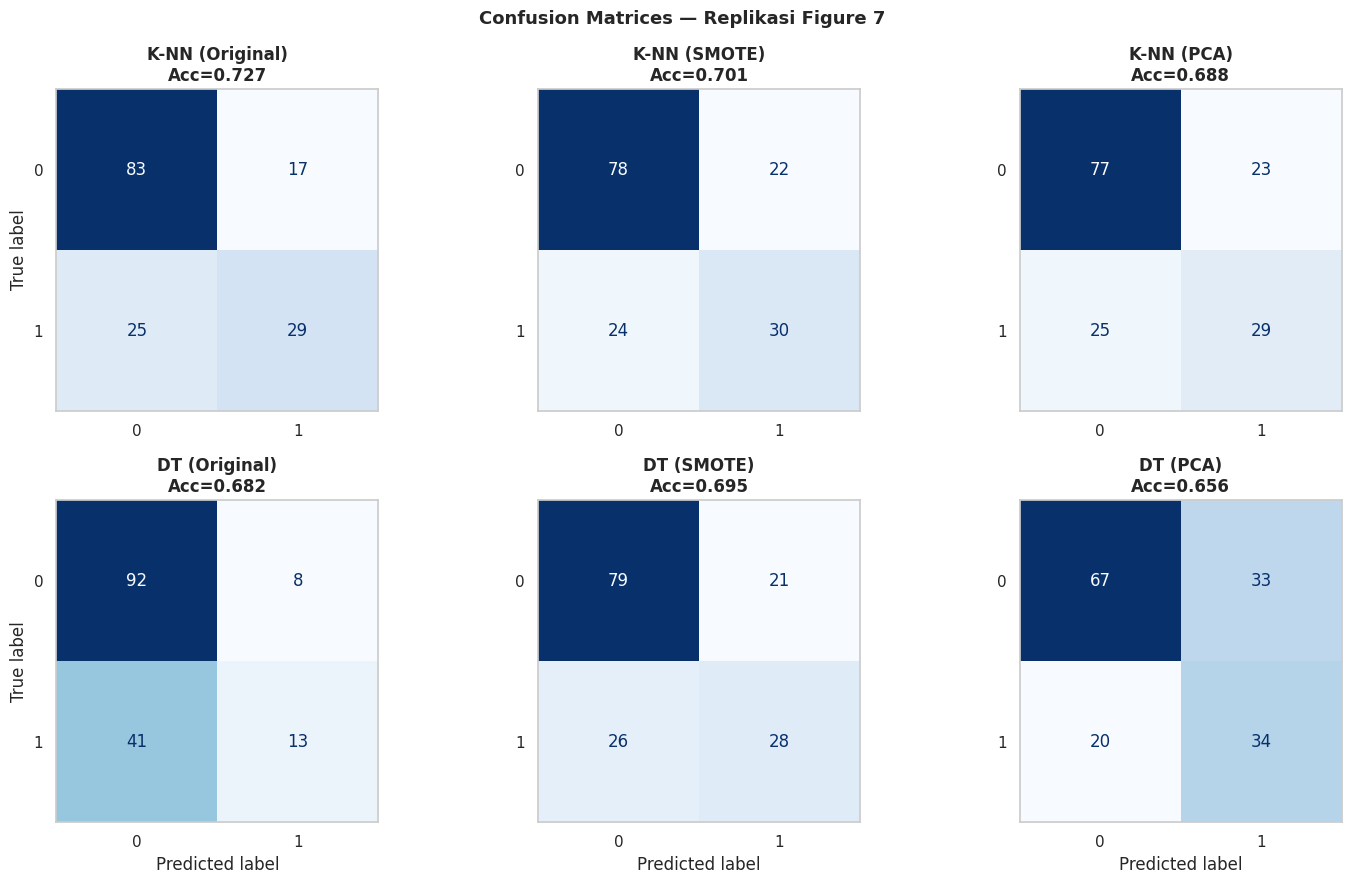

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

plot_pairs = [
    ('KNN(Original)', 'K-NN (Original)'),
    ('KNN(SMOTE)',    'K-NN (SMOTE)'),
    ('KNN(PCA)',      'K-NN (PCA)'),
    ('DT(Original)',  'DT (Original)'),
    ('DT(SMOTE)',     'DT (SMOTE)'),
    ('DT(PCA)',       'DT (PCA)'),
]

for i, (key, title) in enumerate(plot_pairs):
    cm   = confusion_matrix(y_test, all_results[key]['y_pred'])

    # Inisialisasi display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    # Plot dengan mematikan im_kw (garis antar kotak)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues', values_format='d')


    axes[i].grid(False)


    acc = all_results[key]['accuracy']
    axes[i].set_title(f'{title}\nAcc={acc:.3f}', fontweight='bold')


    if i < 3: axes[i].set_xlabel('')
    if i % 3 != 0: axes[i].set_ylabel('')

fig.suptitle('Confusion Matrices — Replikasi Figure 7',
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
print("Best hyperparameters untuk varian SMOTE:")
print("="*55)
for clf_name in ['KNN','BNB','DT','LR','SVM']:
    key = f"{clf_name}(SMOTE)"
    print(f"  {key}: {all_results[key]['best_params']}")

Best hyperparameters untuk varian SMOTE:
  KNN(SMOTE): {'metric': 'euclidean', 'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}
  BNB(SMOTE): {'alpha': 0.5, 'binarize': 0.5}
  DT(SMOTE): {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5}
  LR(SMOTE): {'C': 0.1, 'solver': 'liblinear'}
  SVM(SMOTE): {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
